In [2]:
!pip install xgboost shap

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("telco.csv")
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [7]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [8]:
drop_cols = [
    'Customer ID', 'Country', 'State', 'City', 'Zip Code',
    'Latitude', 'Longitude',
    'Customer Status', 'Churn Score',
    'Churn Category', 'Churn Reason', 'CLTV'
]

df.drop(drop_cols, axis=1, inplace=True)

In [9]:
df['Offer'] = df['Offer'].fillna("No Offer")
df['Internet Type'] = df['Internet Type'].fillna("None")

In [10]:
df[['Offer', 'Internet Type']].isnull().sum()

,0
Offer,0
Internet Type,0


In [11]:
df['Churn'] = df['Churn Label'].map({'Yes':1, 'No':0})
df.drop(['Churn Label'], axis=1, inplace=True)

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Number of Dependents               7043 non-null   int64  
 2   Population                         7043 non-null   int64  
 3   Number of Referrals                7043 non-null   int64  
 4   Tenure in Months                   7043 non-null   int64  
 5   Avg Monthly Long Distance Charges  7043 non-null   float64
 6   Avg Monthly GB Download            7043 non-null   int64  
 7   Monthly Charge                     7043 non-null   float64
 8   Total Charges                      7043 non-null   float64
 9   Total Refunds                      7043 non-null   float64
 10  Total Extra Data Charges           7043 non-null   int64  
 11  Total Long Distance Charges        7043 non-null   float

In [14]:
df = df.astype(int)

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
print(X_train.shape, X_test.shape)

(5634, 44) (1409, 44)


In [17]:
#importing models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [18]:
#training random forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [19]:
#training gradient boosting
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [20]:
#training xgboost
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [21]:
rf.predict(X_test[:5])
gb.predict(X_test[:5])
xgb.predict(X_test[:5])


array([1, 0, 0, 1, 1])

In [22]:
#model eval
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    print("-----", name, "-----")
    print(classification_report(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))
    print("\n")

----- Random Forest -----
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1009
           1       0.98      0.84      0.90       400

    accuracy                           0.95      1409
   macro avg       0.96      0.92      0.94      1409
weighted avg       0.95      0.95      0.95      1409

ROC-AUC: 0.9789816650148663


----- Gradient Boosting -----
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.95      0.86      0.91       400

    accuracy                           0.95      1409
   macro avg       0.95      0.92      0.94      1409
weighted avg       0.95      0.95      0.95      1409

ROC-AUC: 0.9881565906838453


----- XGBoost -----
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.94      0.88      0.91       400

    accuracy                           0.95   

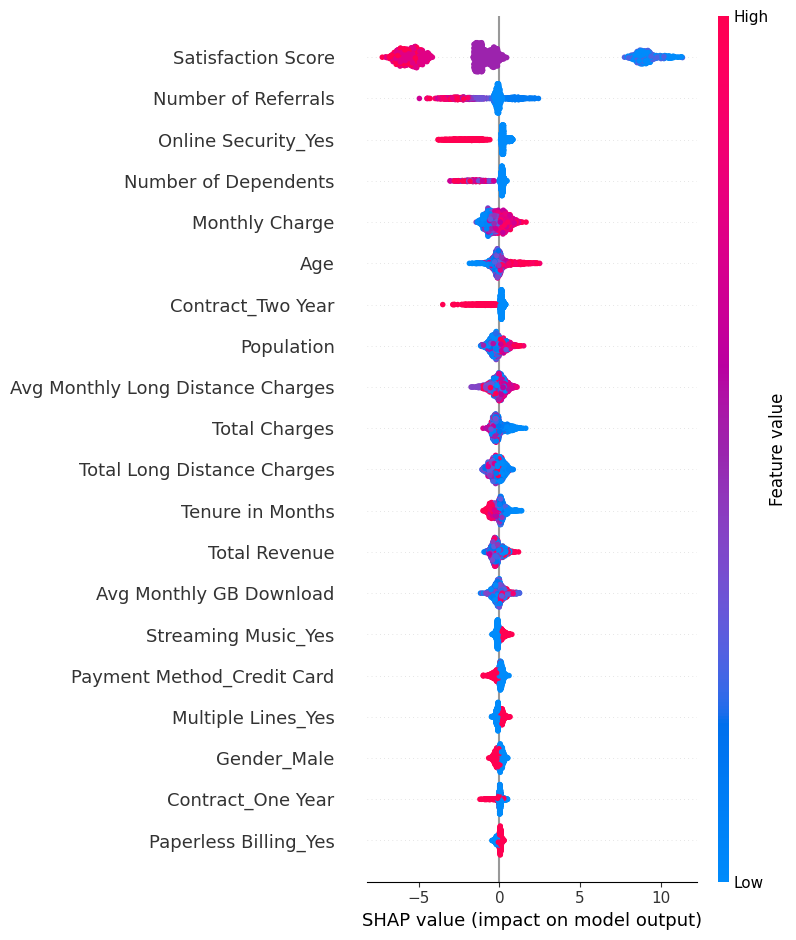

In [23]:
#XAI
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [24]:
#cost sensitive analysis
probs = xgb.predict_proba(X_test)[:,1]

threshold = 0.3
custom_preds = (probs > threshold).astype(int)

In [25]:
#comparison
from sklearn.metrics import classification_report

# Default predictions (threshold = 0.5)
default_preds = xgb.predict(X_test)

print("----- Default Threshold (0.5) -----")
print(classification_report(y_test, default_preds))

# Cost-sensitive predictions (threshold = 0.3)
print("----- Custom Threshold (0.3) -----")
print(classification_report(y_test, custom_preds))

----- Default Threshold (0.5) -----
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1009
           1       0.94      0.88      0.91       400

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409

----- Custom Threshold (0.3) -----
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1009
           1       0.92      0.90      0.91       400

    accuracy                           0.95      1409
   macro avg       0.94      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409



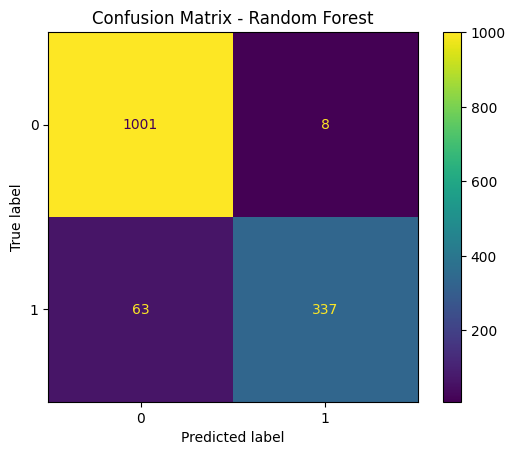

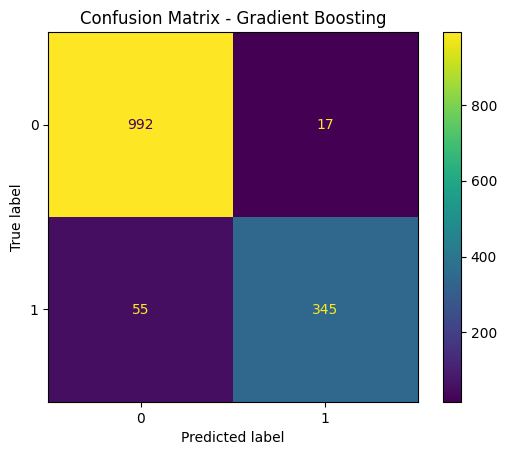

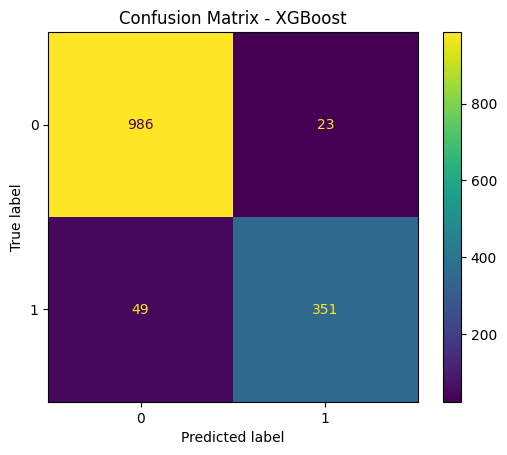

In [26]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

for name, model in models.items():
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

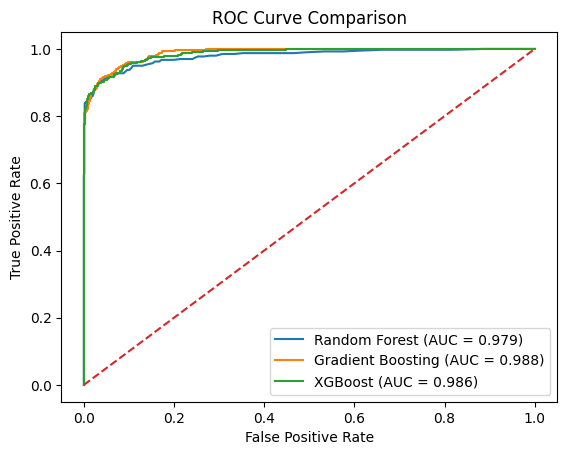

In [27]:
#roc curve plot
from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()